## Package Install

In [ ]:
### 필요한 패키지 설치
!pip install keras
!pip install pandas
!pip install scikit-learn
!pip install matplotlib
!pip install statsmodels
!pip install openpyxl
!pip install xgboost
!pip install Boruta
!pip install asgl

## Main 1. Data Transformation Part

In [1]:
## 저장된 결과 가져오기
import joblib

data = joblib.load("US_Inflation_Full_Backup.joblib")

Y = data['raw_data']['Y']
REAL = data['raw_data']['REAL']
inflation = data['raw_data']['inflation_series']

npred = data['metadata']['npred']
horizons = data['metadata']['horizons']
column_names = data['metadata']['column_names']

for model_name, results in data['individual_model_outputs'].items():
    globals()[f"{model_name}_1"] = results[0]
    globals()[f"{model_name}_2"] = results[1]
    globals()[f"{model_name}_3"] = results[2]

model_preds = data['processed_forecasts']['model_preds_dict']
PRED = data['processed_forecasts']['PRED_df_full']
PRED_1 = data['processed_forecasts']['PRED_h1']
PRED_2 = data['processed_forecasts']['PRED_h2']
PRED_3 = data['processed_forecasts']['PRED_h3']

LOSS1_1, LOSS1_2, LOSS1_3 = data['loss_matrices']['squared_error']
LOSS2_1, LOSS2_2, LOSS2_3 = data['loss_matrices']['absolute_error']

RMSE = data['performance_metrics']['RMSE']
MAE = data['performance_metrics']['MAE']

gw_stat = data['statistical_test_results']['GW_stat']
gw_pval = data['statistical_test_results']['GW_pval']
mcs_rmse_1, mcs_rmse_2, mcs_rmse_3 = data['statistical_test_results']['MCS_RMSE']
mcs_mae_1, mcs_mae_2, mcs_mae_3 = data['statistical_test_results']['MCS_MAE']

In [1]:
import pandas as pd
import numpy as np
import time
from datetime import date

# FRED-MD 2016년 1월 vintage 데이터
data = pd.read_csv("./Data/2016-01.csv")

In [2]:
y1 = np.diff(np.log(data['CPIAUCSL']))[2:]
y2 = np.diff(np.log(data['PCEPI']))[2:]

data = data.drop(columns=['CPIAUCSL', 'PCEPI'])
tcode = data.iloc[0] # 첫 번째 행: Tcode
data = data.iloc[1:, :].reset_index(drop=True) # Tcode 행 제거 
tdata = data.iloc[2:, :].copy().reset_index(drop=True) # 최초 2 표본 제거(2차 차분 고려)

In [3]:
# 정상시계열 변환
for i in range(1, data.shape[1]):
    col = data.columns[i]
    code = int(tcode[i])

    if code == 1:
        tdata[col] = data.iloc[2:, i].values # 그대로

    elif code == 2:
        tdata[col] = data.iloc[1:, i].diff().iloc[1:].values # 1차 차분

    # tcode == 3 (2차 차분)에 해당하는 데이터는 없음

    elif code == 4:
        tdata[col] = np.log(data.iloc[2:, i].values) # log

    elif code == 5:
        tdata[col] = np.diff(np.log(data.iloc[1:, i].values)) # log 취한 뒤 1차 차분

    elif code == 6:
        tdata[col] = np.diff(np.diff(np.log(data.iloc[:, i].values))) # log 취한 뒤 2차 차분

    elif code == 7:
        ratio = data.iloc[1:, i].values / data.iloc[:-1, i].values 
        tdata[col] = np.diff(ratio) # 증가율의 1차 차분

In [4]:
tdata = tdata.iloc[:, 1:] # date 제거, 1960년 1월 ~ 2000년 12월  
Y = pd.concat([pd.Series(y1, name='CPI'), 
               pd.Series(y2, name='PCE'), 
               tdata.reset_index(drop=True)], axis=1)

# Medeiros et al.(2021) 데이터 확인 결과 1960년 2월부터 사용
Y = Y.iloc[:, 1:]

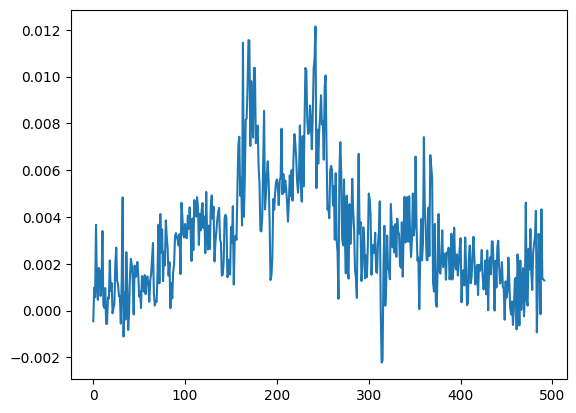

In [5]:
import matplotlib.pyplot as plt

inflation = Y.iloc[:,0]
plt.plot(inflation)

In [6]:
import random
import tensorflow as tf

# Random seed
np.random.seed(21)
random.seed(21)
tf.random.set_seed(21)

## Main 2. Forecasting Part

In [7]:
import ML_Functions as ml
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import PCA

import adaptive_shrinkage as ad

from sklearn.linear_model import LassoCV
import pandas as pd
import cvxpy as cp
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted
from sklearn.model_selection import TimeSeriesSplit
from joblib import Parallel, delayed
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.base import BaseEstimator, RegressorMixin

scaler = MinMaxScaler()
scaler_demean = StandardScaler(with_mean=True, with_std=False)
scaler_std = StandardScaler(with_mean=True, with_std=True)

npred=132

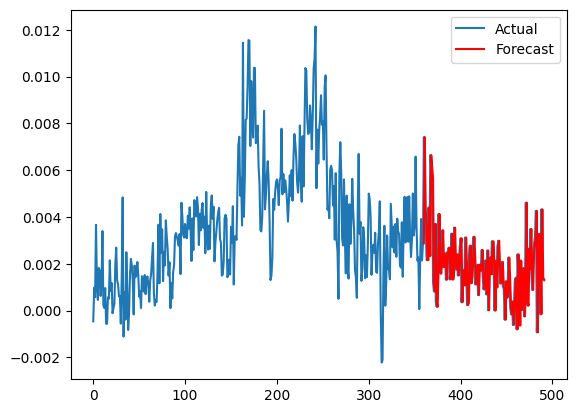

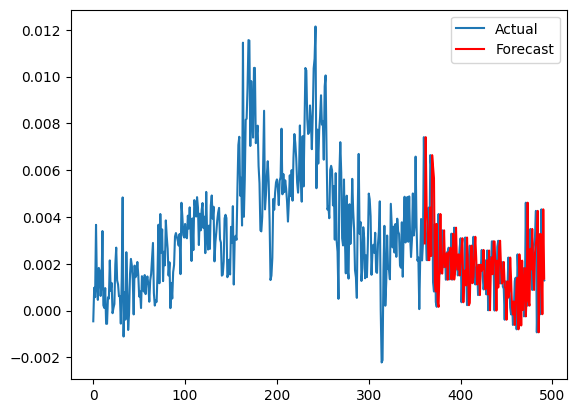

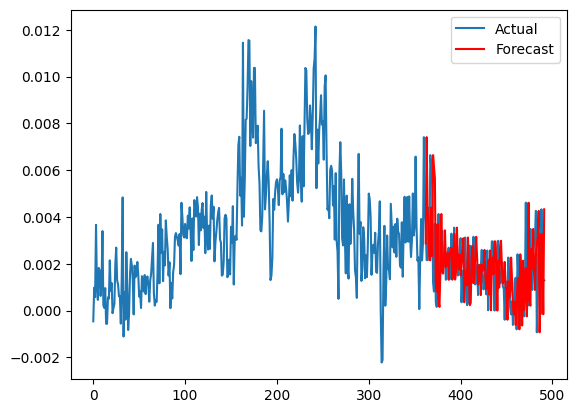

In [8]:
# Random Walk
rw_1 = ml.rw_rolling_window(Y = Y, npred = npred, horizon = 1)
rw_2 = ml.rw_rolling_window(Y = Y, npred = npred, horizon = 2)
rw_3 = ml.rw_rolling_window(Y = Y, npred = npred, horizon = 3)

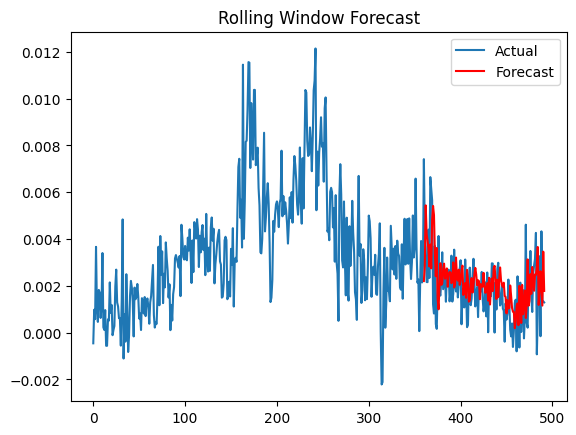

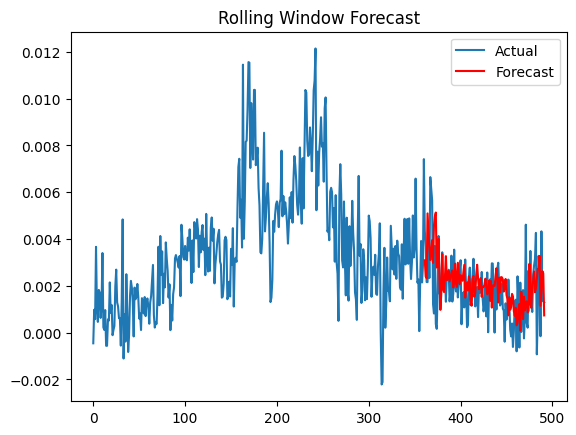

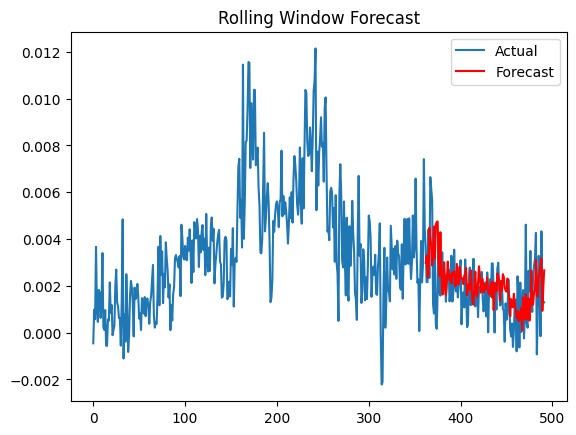

In [9]:
## AR(4) Model ##
from sklearn.linear_model import LinearRegression
from statsmodels.api import OLS, add_constant
import statsmodels.api as sm

ar_1 = ml.ar_rolling_window(Y = Y, npred = npred, lag = 4, horizon = 1)
ar_2 = ml.ar_rolling_window(Y = Y, npred = npred, lag = 4, horizon = 2)
ar_3 = ml.ar_rolling_window(Y = Y, npred = npred, lag = 4, horizon = 3)

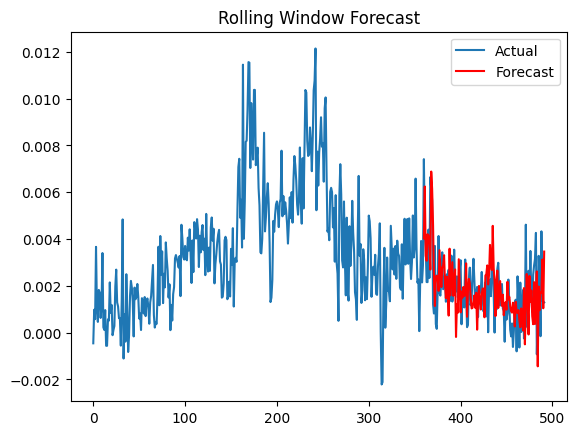

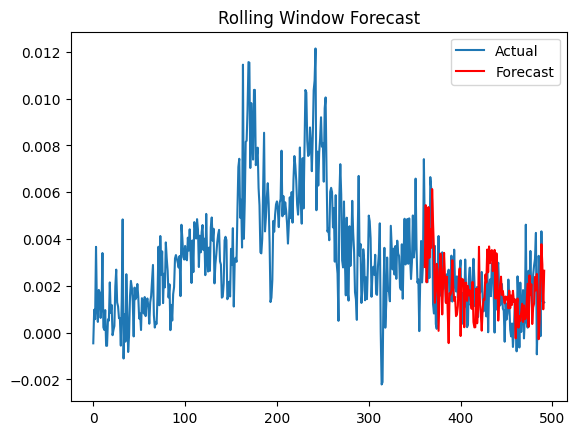

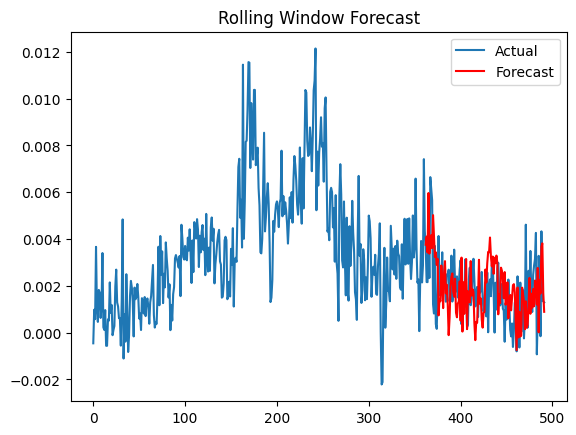

In [10]:
## Ridge Regression, cross-validation 사용 ##
import warnings
warnings.filterwarnings("ignore", category=UserWarning) ## 경고 문구가 과도하게 뜨는 것을 방지하기 위한 코드

ridge_1 = ml.shrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 1, alpha=0.0)
ridge_2 = ml.shrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 2, alpha=0.0)
ridge_3 = ml.shrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 3, alpha=0.0)

In [ ]:
## LASSO ##
from sklearn.linear_model import ElasticNetCV

lasso_1 = ml.shrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 1, alpha=1)
lasso_2 = ml.shrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 2, alpha=1)
lasso_3 = ml.shrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 3, alpha=1)

In [ ]:
## Adaptive LASSO ##
adalasso_1 = ad.adaptshrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 1, alpha=1)
adalasso_2 = ad.adaptshrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 2, alpha=1)
adalasso_3 = ad.adaptshrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 3, alpha=1)

Starting parallel processing for 132 windows...


In [ ]:
## Elastic Net ##
elasticnet_1 = ml.shrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 1, alpha=0.5)
elasticnet_2 = ml.shrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 2, alpha=0.5)
elasticnet_3 = ml.shrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 3, alpha=0.5)

In [ ]:
## Adaptive ElasticNet ##
adaelastic_1 = ad.adaptshrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 1, alpha=0.5)
adaelastic_2 = ad.adaptshrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 2, alpha=0.5)
adaelastic_3 = ad.adaptshrinkage_cv_rolling_window(Y = Y, npred = npred, horizon = 3, alpha=0.5)

In [ ]:
## Complete Subset Regression (CSR) ##
csr_1 = ml.csr_rolling_window(Y = Y, npred = npred, horizon = 1)
csr_2 = ml.csr_rolling_window(Y = Y, npred = npred, horizon = 2)
csr_3 = ml.csr_rolling_window(Y = Y, npred = npred, horizon = 3)

In [ ]:
## Target Factors ##
tfact_1 = ml.tfact_rolling_window(Y, npred = npred, horizon = 1)
tfact_2 = ml.tfact_rolling_window(Y, npred = npred, horizon = 2)
tfact_3 = ml.tfact_rolling_window(Y, npred = npred, horizon = 3)

In [ ]:
## Random Forest (RF) ##
from sklearn.ensemble import RandomForestRegressor

rf_1 = ml.rf_rolling_window(Y, npred = npred, horizon = 1)
rf_2 = ml.rf_rolling_window(Y, npred = npred, horizon = 2)
rf_3 = ml.rf_rolling_window(Y, npred = npred, horizon = 3)

In [ ]:
## XGBoost ##
import xgboost as xgb

xgb_1 = ml.xgb_rolling_window(Y, npred, 1)
xgb_2 = ml.xgb_rolling_window(Y, npred, 2)
xgb_3 = ml.xgb_rolling_window(Y, npred, 3)

In [ ]:
## Neural Networks(Deep Learning) ##
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

nn_1 = ml.nn_rolling_window(Y, npred = npred, horizon = 1)
nn_2 = ml.nn_rolling_window(Y, npred = npred, horizon = 2)
nn_3 = ml.nn_rolling_window(Y, npred = npred, horizon = 3)

In [ ]:
## LSTM ##
from tensorflow.keras.layers import LSTM, Dense

lstm_1 = ml.rolling_window_lstm_single(Y, npred = npred, horizon = 1)
lstm_2 = ml.rolling_window_lstm_single(Y, npred = npred, horizon = 2)
lstm_3 = ml.rolling_window_lstm_single(Y, npred = npred, horizon = 3)

## Main 3. Predicted Value and Loss Table

In [ ]:
model_preds = {
    "rw": [rw_1["pred"], rw_2["pred"], rw_3["pred"]],
    "ar": [ar_1["pred"], ar_2["pred"], ar_3["pred"]],
    "ridge": [ridge_1["pred"], ridge_2["pred"], ridge_3["pred"]],
    "lasso": [lasso_1["pred"], lasso_2["pred"], lasso_3["pred"]],
    "adalasso": [adalasso_1["pred"], adalasso_2["pred"], adalasso_3["pred"]],
    "elasticnet": [elasticnet_1["pred"], elasticnet_2["pred"], elasticnet_3["pred"]],
    "adaelasticnet": [adaelastic_1["pred"], adaelastic_2["pred"], adaelastic_3["pred"]],
    "csr": [csr_1["pred"], csr_2["pred"], csr_3["pred"]],
    "tfact": [tfact_1["pred"], tfact_2["pred"], tfact_3["pred"]],
    "rf": [rf_1["pred"], rf_2["pred"], rf_3["pred"]],
    "xgb": [xgb_1["pred"], xgb_2["pred"], xgb_3["pred"]],
    "nn": [nn_1["pred"], nn_2["pred"], nn_3["pred"]],
    "lstm": [lstm_1["pred"], lstm_2["pred"], lstm_3["pred"]],
}

model_forecasts = {}
for model, preds in model_preds.items():
    mat = np.full((npred, 3), np.nan)
    for h in range(3):
        horizon_len = npred - h
        mat[-horizon_len:, h] = preds[h][-horizon_len:]
    df = pd.DataFrame(mat, columns=["h=1", "h=2", "h=3"])
    model_forecasts[f"{model}_d_pred_df"] = df

PRED = pd.concat(model_forecasts.values(), axis=1)


In [ ]:
### Horizon에 따라 결과를 구분하여 저장
PRED_1 = PRED.iloc[:, [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36]]
PRED_2 = PRED.iloc[:, [1, 4, 7, 10, 13, 16, 19, 22, 25, 28, 31, 34, 37]]
PRED_3 = PRED.iloc[:, [2, 5, 8, 11, 14, 17, 20, 23, 26, 29, 32, 35, 38]]

In [ ]:
### 실제값을 저장
REAL = Y.iloc[:, 0][-npred:]

In [ ]:
### 실제값과 예측치의 차이를 저장하기
# LOSS1: Squared error
LOSS1_1 = (PRED_1.reset_index(drop=True) - REAL.iloc[-npred:].reset_index(drop=True).values.reshape(-1, 1)) ** 2
LOSS1_2 = (PRED_2.iloc[-(npred-1):, :].reset_index(drop=True) - REAL.iloc[-(npred-1):].reset_index(drop=True).values.reshape(-1, 1)) ** 2
LOSS1_3 = (PRED_3.iloc[-(npred-2):, :].reset_index(drop=True) - REAL.iloc[-(npred-2):].reset_index(drop=True).values.reshape(-1, 1)) ** 2

# LOSS2: Absolute error
LOSS2_1 = (PRED_1.reset_index(drop=True) - REAL.iloc[-npred:].reset_index(drop=True).values.reshape(-1, 1)).abs()
LOSS2_2 = (PRED_2.iloc[-(npred-1):, :].reset_index(drop=True) - REAL.iloc[-(npred-1):].reset_index(drop=True).values.reshape(-1, 1)).abs()
LOSS2_3 = (PRED_3.iloc[-(npred-2):, :].reset_index(drop=True) - REAL.iloc[-(npred-2):].reset_index(drop=True).values.reshape(-1, 1)).abs()

In [ ]:
### 모형에 따라 각 열의 이름 지정
column_names = [
    "RW", "AR", "Ridge", "LASSO", "Adaptive LASSO", "Elasticnet","Adaptive Elasticnet",
    "CSR", "Target factor","Random forest","XGBoost", "Neural Net", "LSTM"
]
horizons = ["1m", "2m", "3m"]

LOSS1_1.columns = column_names[:LOSS1_1.shape[1]]
LOSS1_2.columns = column_names[:LOSS1_2.shape[1]]
LOSS1_3.columns = column_names[:LOSS1_3.shape[1]]

LOSS2_1.columns = column_names[:LOSS2_1.shape[1]]
LOSS2_2.columns = column_names[:LOSS2_2.shape[1]]
LOSS2_3.columns = column_names[:LOSS2_3.shape[1]]


In [ ]:
RMSE = pd.DataFrame(index=column_names, columns=horizons)
MAE = pd.DataFrame(index=column_names, columns=horizons)

RMSE["1m"] = np.sqrt(LOSS1_1.mean())
RMSE["2m"] = np.sqrt(LOSS1_2.mean())
RMSE["3m"] = np.sqrt(LOSS1_3.mean())

MAE["1m"] = LOSS2_1.mean()
MAE["2m"] = LOSS2_2.mean()
MAE["3m"] = LOSS2_3.mean()

In [ ]:
RMSE

,1m,2m,3m
RW,0.001705,0.001833,0.001657
AR,0.001560,0.001383,0.001364
Ridge,0.001467,0.001568,0.001532
LASSO,0.001427,0.001404,0.001378
Adaptive LASSO,0.001571,0.001613,0.001615
Elasticnet,0.001427,0.001404,0.001378
Adaptive Elasticnet,0.001404,0.001467,0.001403
CSR,0.001705,0.001730,0.001721
Target factor,0.001445,0.001458,0.001427
Random forest,0.001367,0.001426,0.001490


In [ ]:
MAE

,1m,2m,3m
RW,0.001312,0.001449,0.001236
AR,0.001211,0.001088,0.001061
Ridge,0.001182,0.001251,0.001213
LASSO,0.001108,0.001089,0.001035
Adaptive LASSO,0.001233,0.001285,0.001262
Elasticnet,0.001108,0.001090,0.001035
Adaptive Elasticnet,0.001092,0.001209,0.001091
CSR,0.001378,0.001406,0.001408
Target factor,0.001124,0.001156,0.001108
Random forest,0.001077,0.001148,0.001188


## Main 4. US inflation test

In [ ]:
from statsmodels.stats.sandwich_covariance import cov_hac, cov_white_simple
from scipy.stats import norm
from itertools import combinations
from scipy.stats import t

### GW test

In [ ]:
def run_gw_test(model_pred, benchmark_pred, real, npred, horizons):
    stat = [np.nan] * len(horizons)
    pval = [np.nan] * len(horizons)
    for idx, h in enumerate(horizons):
        m_p = model_pred[:, idx]
        b_p = benchmark_pred[:, idx]
        
        valid_mask = ~np.isnan(m_p) & ~np.isnan(b_p)
        m_v = m_p[valid_mask]
        b_v = b_p[valid_mask]
        r_v = real[valid_mask]
        
        T_h = len(m_v)
        if T_h > 0:
            gw = ml.gw_test(m_v, b_v, r_v, tau=h, T=T_h, method="NeweyWest")
            stat[idx] = gw["statistic"]
            pval[idx] = gw["p_value"]
            
    return {"stat": stat, "pval": pval}

In [ ]:
num_models = PRED.shape[1] // 3
model_names = [f"model_{i+1}" for i in range(num_models)]
horizons_list = [1, 2, 3]

multi_cols = pd.MultiIndex.from_product([model_names, [f"h={h}" for h in horizons_list]], names=["Model", "Horizon"])
PRED.columns = multi_cols

model_dfs = {
    model: PRED.loc[:, model].to_numpy()
    for model in model_names
}

benchmark_model = "model_1" ## Random walk model
real_arr = REAL.to_numpy()

results = {}
for i, model in enumerate(model_names):
    if model != benchmark_model:
        results[column_names[i]] = run_gw_test(model_dfs[model], model_dfs[benchmark_model], real_arr, npred, horizons_list)

In [ ]:
gw_stat = pd.DataFrame({k: v["stat"] for k, v in results.items()}).T
gw_pval = pd.DataFrame({k: v["pval"] for k, v in results.items()}).T

gw_stat.columns = [f"h={h}" for h in horizons_list]
gw_pval.columns = [f"h={h}" for h in horizons_list]

gw_stat = gw_stat.round(2)
gw_pval = gw_pval.round(3)

In [ ]:
gw_stat

,h=1,h=2,h=3
AR,-1.00,-3.62,-1.80
Ridge,-1.54,-2.29,-0.25
LASSO,-3.23,-4.71,-2.36
Adaptive LASSO,-0.74,-1.50,0.20
Elasticnet,-3.23,-4.70,-2.36
Adaptive Elasticnet,-2.95,-2.82,-1.62
CSR,0.62,-0.35,1.27
Target factor,-3.40,-4.06,-1.44
Random forest,-3.25,-3.31,-0.48
XGBoost,-3.05,-3.56,-0.84


### MCS test

In [ ]:
mcs_rmse_1 = ml.MCSprocedure_py(LOSS1_1, alpha=0.5, B=1000, verbose=True, statistic="Tmax")
mcs_rmse_2 = ml.MCSprocedure_py(LOSS1_2, alpha=0.5, B=1000, verbose=True, statistic="Tmax")
mcs_rmse_3 = ml.MCSprocedure_py(LOSS1_3, alpha=0.5, B=1000, verbose=True, statistic="Tmax")

Model RW eliminated at p = 0.0410
Model CSR eliminated at p = 0.0210
Model LSTM eliminated at p = 0.2280
Model AR eliminated at p = 0.3590
Model Adaptive LASSO eliminated at p = 0.2420
Model Neural Net eliminated at p = 0.2490
Model Ridge eliminated at p = 0.3740
Model LASSO eliminated at p = 0.4870
Model Target factor eliminated at p = 0.4180
Model Elasticnet eliminated at p = 0.2520
Model Neural Net eliminated at p = 0.0020
Model RW eliminated at p = 0.0100
Model CSR eliminated at p = 0.0050
Model Adaptive LASSO eliminated at p = 0.1140
Model Ridge eliminated at p = 0.1710
Model Neural Net eliminated at p = 0.0030
Model CSR eliminated at p = 0.0220


In [ ]:
print(mcs_rmse_1['SSM'])
print(mcs_rmse_2['SSM'])
print(mcs_rmse_3['SSM'])

                          v_M       v_R      Loss
XGBoost             -0.662621 -0.289867  0.000002
Random forest       -0.457703  0.289867  0.000002
Adaptive Elasticnet  0.683295  0.697041  0.000002
                          v_M       v_R      Loss
AR                  -0.717546 -0.092221  0.000002
LSTM                -0.583983  0.092221  0.000002
Elasticnet          -0.578281  0.303981  0.000002
LASSO               -0.578072  0.304061  0.000002
Random forest        0.192603  0.732498  0.000002
XGBoost              0.113753  0.685429  0.000002
Target factor        0.799468  1.031583  0.000002
Adaptive Elasticnet  0.941215  1.298995  0.000002
                          v_M       v_R      Loss
AR                  -1.813338 -0.202379  0.000002
LASSO               -3.835418  0.202379  0.000002
Elasticnet          -3.835593  0.246067  0.000002
Adaptive Elasticnet -2.233303  0.563365  0.000002
Target factor       -1.600457  1.033905  0.000002
XGBoost             -0.508495  1.645557  0.000002


In [ ]:
mcs_mae_1 = ml.MCSprocedure_py(LOSS2_1, alpha=0.5, B=1000, verbose=True, statistic="Tmax")
mcs_mae_2 = ml.MCSprocedure_py(LOSS2_2, alpha=0.5, B=1000, verbose=True, statistic="Tmax")
mcs_mae_3 = ml.MCSprocedure_py(LOSS2_3, alpha=0.5, B=1000, verbose=True, statistic="Tmax")

Model CSR eliminated at p = 0.0310
Model RW eliminated at p = 0.0430
Model LSTM eliminated at p = 0.3630
Model Neural Net eliminated at p = 0.3930
Model AR eliminated at p = 0.3450
Model Adaptive LASSO eliminated at p = 0.3160
Model Ridge eliminated at p = 0.2780
Model Neural Net eliminated at p = 0.0000
Model RW eliminated at p = 0.0050
Model CSR eliminated at p = 0.0040
Model Adaptive LASSO eliminated at p = 0.1060
Model Ridge eliminated at p = 0.1080
Model Adaptive Elasticnet eliminated at p = 0.2360
Model Target factor eliminated at p = 0.4620
Model Random forest eliminated at p = 0.3010
Model Neural Net eliminated at p = 0.0030
Model CSR eliminated at p = 0.0060
Model Adaptive LASSO eliminated at p = 0.4080


In [ ]:
print(mcs_mae_1['SSM'])
print(mcs_mae_2['SSM'])
print(mcs_mae_3['SSM'])

                          v_M       v_R      Loss
Random forest       -0.686242 -0.229508  0.001077
XGBoost             -0.499089  0.229508  0.001083
Adaptive Elasticnet -0.180353  0.243119  0.001092
Elasticnet           0.550481  0.702549  0.001108
LASSO                0.553490  2.304890  0.001108
Target factor        0.826347  0.932500  0.001124
                 v_M       v_R      Loss
AR         -0.209404 -0.024587  0.001088
LASSO      -0.337719  0.024587  0.001089
Elasticnet -0.321665  0.989267  0.001090
LSTM        0.107161  0.222873  0.001102
XGBoost     0.539200  0.572099  0.001117
                          v_M       v_R      Loss
LASSO               -3.538125 -0.513122  0.001035
Elasticnet          -3.538068  0.688918  0.001035
AR                  -1.593184  0.513122  0.001061
Adaptive Elasticnet -1.189460  1.237969  0.001091
Target factor       -0.614176  1.480969  0.001108
XGBoost              0.537754  2.451388  0.001155
Random forest        1.282268  2.974886  0.001188
Ridg

### Save Results

In [ ]:
import joblib
from datetime import date

comprehensive_workspace = {
    "metadata": {
        "export_date": str(date.today()),
        "npred": npred,
        "horizons": horizons,
        "column_names": column_names
    },
    "raw_data": {
        "Y": Y,
        "REAL": REAL,
        "inflation_series": inflation
    },
    "individual_model_outputs": {
        "rw": [rw_1, rw_2, rw_3],
        "ar": [ar_1, ar_2, ar_3],
        "ridge": [ridge_1, ridge_2, ridge_3],
        "lasso": [lasso_1, lasso_2, lasso_3],
        "adalasso": [adalasso_1, adalasso_2, adalasso_3],
        "elasticnet": [elasticnet_1, elasticnet_2, elasticnet_3],
        "adaelastic": [adaelastic_1, adaelastic_2, adaelastic_3],
        "csr": [csr_1, csr_2, csr_3],
        "tfact": [tfact_1, tfact_2, tfact_3],
        "rf": [rf_1, rf_2, rf_3],
        "xgb": [xgb_1, xgb_2, xgb_3],
        "nn": [nn_1, nn_2, nn_3],
        "lstm": [lstm_1, lstm_2, lstm_3]
    },
    "processed_forecasts": {
        "model_preds_dict": model_preds,
        "PRED_df_full": PRED,
        "PRED_h1": PRED_1,
        "PRED_h2": PRED_2,
        "PRED_h3": PRED_3
    },
    "loss_matrices": {
        "squared_error": [LOSS1_1, LOSS1_2, LOSS1_3],
        "absolute_error": [LOSS2_1, LOSS2_2, LOSS2_3]
    },
    "performance_metrics": {
        "RMSE": RMSE,
        "MAE": MAE
    },
    "statistical_test_results": {
        "GW_stat": gw_stat,
        "GW_pval": gw_pval,
        "MCS_RMSE": [mcs_rmse_1, mcs_rmse_2, mcs_rmse_3],
        "MCS_MAE": [mcs_mae_1, mcs_mae_2, mcs_mae_3]
    }
}

save_filename = "US_Inflation_Full_Backup.joblib"

joblib.dump(comprehensive_workspace, save_filename, compress=3)